In [74]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy import stats

Определяем положение и параметры электрозаправки, а именно её координаты в пространстве, радиус зоны попадания и скорость зарядки в шаг

In [75]:
TARGET_POS = np.array([18.0, 6.0])
TARGET_RADIUS = 0.7
CHARGING_POWER = 0.02

Задаём три прямоугольных препятствия, чтобы дрону приходилось прокладывать траекторию, обходя их

In [76]:
OBSTACLES = [
    (12.5, 13.5, 3.0, 4.5),
    (14.0, 15.0, 7.5, 9.0),
    (16.5, 17.5, 2.0, 5.0)
]

Определяем дискретные уровни командной скорости дрона, которые он может выбирать на каждом шаге

In [77]:
ACTION_SPEEDS = [0.08, 0.22, 0.38]

Описываем, какие величины скорости агент может видеть в состоянии

In [78]:
STATE_SPEEDS = np.array([0.08, 0.22, 0.38, 0.55])

4 дискретных направления движения, что в купе с тремя скоростями это формирует дискретное пространство действий.

In [79]:
DIRS = [0, np.pi/2, np.pi, -np.pi/2]

Определяю среду для задачи зарядки дрона с препятствиями, ветром и станцией.

In [80]:
class DroneEnv:
    def __init__(self):
        # сразу инициализирую состояние среды
        self.reset()

    def reset(self):
        # стартую из нормального распределения вокруг (2.5, 5.0) и режу по X, чтобы дрон не появлялся за пределами карты
        self.x = np.clip(np.random.normal(2.5, 1.5), 0.5, 6.0)
        self.y = np.clip(np.random.normal(5.0, 1.5), 0.5, 11.5)
        # одинаковый заряд для всех
        self.charge = 0.6
        self.steps = 0
        self.wind = np.zeros(2)
        self.update_wind()
        # переменная под фактическую скорость с учетом ветра
        self.last_v_real = 0.0
        return self.get_state()

    def update_wind(self):
        # каждый раз перекидываю случайный ветер в небольшом диапазоне
        self.wind = np.random.uniform(-0.08, 0.08, 2)

    def get_state(self):
        # смещение до станции
        dx = TARGET_POS[0] - self.x
        dy = TARGET_POS[1] - self.y

        # дискретизируем пространство в 12x12
        dx_bin = int(np.clip((dx + 2.0) / 22.0 * 12, 0, 11))
        dy_bin = int(np.clip((dy + 6.0) / 12.0 * 12, 0, 11))

        # заряд тоже режется на 10 уровней
        c_bin = int(np.clip(self.charge * 10, 0, 9))
        # скорость кодирую ближайшим бином к реальной
        s_bin = (np.abs(STATE_SPEEDS - self.last_v_real)).argmin()

        return (dx_bin, dy_bin, c_bin, s_bin)

    def step(self, action_idx):
        # действие, беру скорость и направление из индекса 0..11
        speed_idx = action_idx % 3
        dir_idx = action_idx // 3

        v_cmd = ACTION_SPEEDS[speed_idx]
        theta = DIRS[dir_idx]

        # раз в 20 шагов меняю ветер
        if self.steps > 0 and self.steps % 20 == 0:
            self.update_wind()

        # скорость + ветер
        vx = v_cmd * np.cos(theta) + self.wind[0]
        vy = v_cmd * np.sin(theta) + self.wind[1]

        # сохраняем, как быстро реально летим
        self.last_v_real = np.sqrt(vx**2 + vy**2)

        new_x = self.x + vx
        new_y = self.y + vy

        # проверяем, не влетели ли в один из прямоугольников
        collision = False
        for (ox1, ox2, oy1, oy2) in OBSTACLES:
            if ox1 <= new_x <= ox2 and oy1 <= new_y <= oy2:
                collision = True
                break

        # при столкновении не двигаемся
        if not collision:
            self.x = new_x
            self.y = new_y

        # расход аккумулятора зависит скорости и ответра
        wind_sq = np.sum(self.wind**2)
        drain = 0.015 * (v_cmd**2) + 0.002 * wind_sq
        self.charge -= drain

        # проверяем, попали ли в область таргета
        dist = np.linalg.norm([self.x - TARGET_POS[0], self.y - TARGET_POS[1]])
        in_station = dist < TARGET_RADIUS

        charge_gain = 0.0
        if in_station:
            charge_gain = CHARGING_POWER
            self.charge += charge_gain

        # не даем заряду уходить за [0, 1]
        self.charge = np.clip(self.charge, 0.0, 1.0)
        self.steps += 1

        # шаг всегда стоит денег + штраф за скорость и бонус за зарядку
        reward = -0.8 - 0.025 * (v_cmd**2) + 0.1 * charge_gain
        done = False
        status = "flying"

        # идеальный кейс
        if in_station and self.charge > 0.92:
            if self.steps <= 120:
                reward += 80
                done = True
                status = "success"
            else:
                # заряд есть, но не уложились по времени
                done = True
                status = "timeout_charged"

        # провал по батарейке
        elif self.charge < 0.05:
            reward -= 150
            done = True
            status = "fail_battery"

        # провал по лимиту шагов
        elif self.steps >= 180:
            done = True
            status = "fail_timeout"

        return self.get_state(), reward, done, status

Для поведенческой модели было решено использоват функцию полезности Канемана Тверски:

                x^α,              если x >= 0

                -λ * (-x)^β,      если x < 0

Определяю класс агента для табличного Q-learning с eps‑greedy и поддержкой двух режимов, обычный и поведенческий, где TD‑ошибка пропускается через функцию полезности Канемана–Тверски с заданными параметрами.

In [81]:
class DroneAgent:
    def __init__(self, mode='rational'):
        self.q_table = defaultdict(float)
        self.mode = mode
        # гиперпараметры Q-Learning
        self.lr = 0.1
        self.gamma = 0.95
        self.epsilon = 1.0
        self.eps_min = 0.01
        self.eps_decay = 0.997
        # параметры функции полезности Канемана–Тверски для поведенческого агента
        self.pt_alpha = 0.88
        self.pt_beta = 0.88
        self.pt_lambda = 2.35

    def get_action(self, state):
        # eps greedy, с вероятностью eps исследуем, иначе берём жадное действие по Q таблице
        if np.random.random() < self.epsilon:
            return np.random.randint(12)

        qs = [self.q_table[(state, a)] for a in range(12)]
        if all(q == 0 for q in qs):
            # если про это состояние ещё ничего не знаем, то тоже исследуем
            return np.random.randint(12)
        return np.argmax(qs)

    def utility_function(self, td_error):
        # рациональный агент использует чистую TD-error
        if self.mode == 'rational':
            return td_error
        # поведенческий агент искажает ошибку по Prospect Theory
        if td_error >= 0:
            return td_error ** self.pt_alpha
        else:
            # потери воспринимаются сильнее за счёт lambda
            return -self.pt_lambda * ((-td_error) ** self.pt_beta)

    def update(self, s, a, r, ns, done):
        old_q = self.q_table[(s, a)]
        if done:
            target = r
        else:
            next_max = max([self.q_table[(ns, na)] for na in range(12)])
            target = r + self.gamma * next_max

        td_error = target - old_q
        perceived_error = self.utility_function(td_error)
        self.q_table[(s, a)] = old_q + self.lr * perceived_error

    def decay(self):
        # плавно уменьшаем eps, пока не дойдём до нижней границы
        if self.epsilon > self.eps_min:
            self.epsilon *= self.eps_decay

Определяю функцию обучения агента. В каждом эпизоде агент взаимодействует со средой, обновляет Q-таблицу с учётом reward и после эпизода уменьшается eps. Было решено подмешивать простой shaping вида (prev_dist - curr_dist) * 2.0, чтобы успеть обучиться за 150000 итераций

In [86]:
def train_sim(agent_type, episodes=15000):
    env = DroneEnv()
    agent = DroneAgent(agent_type)
    rewards_log = []

    print(f"Start Training: {agent_type}")

    for ep in range(episodes):
        state = env.reset()
        done = False
        total_clean_reward = 0

        # считаем стартовое расстояние до станции — от него будем строить shaping
        prev_dist = np.linalg.norm([env.x - TARGET_POS[0], env.y - TARGET_POS[1]])

        while not done:
            action = agent.get_action(state)
            next_state, r, done, status = env.step(action)

            # смотрим, приблизились ли мы к станции за шаг
            curr_dist = np.linalg.norm([env.x - TARGET_POS[0], env.y - TARGET_POS[1]])
            shaping = (prev_dist - curr_dist) * 2.0

            # в обучение подмешиваю shaping, как подсказку по направлению движения, что сильно ускоряет обучение
            agent.update(state, action, r + shaping, next_state, done)

            state = next_state
            # в лог пишу только чистую награду по ТЗ, без shaping
            total_clean_reward += r
            prev_dist = curr_dist

        # после каждого эпизода немного уменьшаем epsilon
        agent.decay()
        rewards_log.append(total_clean_reward)

        if ep % 2000 == 0:
            print(f"Ep {ep}: AvgR={np.mean(rewards_log[-100:]):.1f}, Eps={agent.epsilon:.3f}")

    return agent, rewards_log

In [87]:
def run_tests(agent, num_tests=300):
    env = DroneEnv()
    # на этапе тестов почти отключаем исследование
    agent.epsilon = 0.005
    stats = {
        'success': 0,
        'times': [], # время для успешных
        'charge_success': [],
        'final_charge': [],
        'energy_used': [],
        'collisions': 0,
        'trajectories': []
    }

    for _ in range(num_tests):
        state = env.reset()
        done = False
        traj = {'x': [], 'y': []}
        start_charge = env.charge
        had_collision_in_ep = False
        while not done:
            # сохраняю траекторию полёта для последующей визуализации
            traj['x'].append(env.x)
            traj['y'].append(env.y)

            # запоминаем позицию до шага
            prev_x, prev_y = env.x, env.y
            action = agent.get_action(state)
            state, _, done, status = env.step(action)

            # если пытались двигаться, но координаты не изменились, то считаем как столкновение
            speed_idx = action % 3
            if speed_idx > 0:
                if np.isclose(prev_x, env.x) and np.isclose(prev_y, env.y):
                    had_collision_in_ep = True

        stats['final_charge'].append(env.charge)
        if had_collision_in_ep:
            stats['collisions'] += 1
        if status == 'success':
            stats['success'] += 1
            stats['times'].append(env.steps)
            stats['charge_success'].append(env.charge)
            # оцениваем, сколько энергии реально ушло на полет с учетом дозарядки
            used = start_charge - env.charge + (env.steps * CHARGING_POWER)
            stats['energy_used'].append(used)

        # сохраняю первые несколько траекторий, чтобы потом их отрисовать
        if len(stats['trajectories']) < 4:
            stats['trajectories'].append(traj)

    return stats

Запускаю обучение агентов, тестирование, строю графики и вывожу метрики с t-тестом.


In [88]:
rational_agent, rat_hist = train_sim('rational', episodes=15000)
prospect_agent, pro_hist = train_sim('behavioral', episodes=15000)

Start Training: rational
Ep 0: AvgR=-144.3, Eps=0.997
Ep 2000: AvgR=15.4, Eps=0.010
Ep 4000: AvgR=22.4, Eps=0.010
Ep 6000: AvgR=23.9, Eps=0.010
Ep 8000: AvgR=18.8, Eps=0.010
Ep 10000: AvgR=19.8, Eps=0.010
Ep 12000: AvgR=21.0, Eps=0.010
Ep 14000: AvgR=21.1, Eps=0.010
Start Training: behavioral
Ep 0: AvgR=-144.3, Eps=0.997
Ep 2000: AvgR=-115.7, Eps=0.010
Ep 4000: AvgR=-28.5, Eps=0.010
Ep 6000: AvgR=8.4, Eps=0.010
Ep 8000: AvgR=16.8, Eps=0.010
Ep 10000: AvgR=18.1, Eps=0.010
Ep 12000: AvgR=20.9, Eps=0.010
Ep 14000: AvgR=22.2, Eps=0.010


Прогоняю по 300 тестов для каждого агента для сбора метрик

In [89]:
rat_stats = run_tests(rational_agent)
pro_stats = run_tests(prospect_agent)

Определяю функцию для сглаживания награды скользящим средним

In [90]:
def moving_average(data, window=150):
    return np.convolve(data, np.ones(window)/window, mode='valid')

Поведенческая модель начинает с значительно более низких наград и обучается медленнее, чем рациональная, однако после ~4000 эпизодов она не только догоняет рациональную модель, но и демонстрирует меньшую дисперсию

Медленный старт это следствие гиперчувствительности к потерям по λ=2.35. Модель на ранних этапах крайне неохотно исследует действия, ведущие к любым штрафам,однако усвоив безопасные паттерны, она действует стабильнее, что видно по меньшим колебаниям награды после сходимости

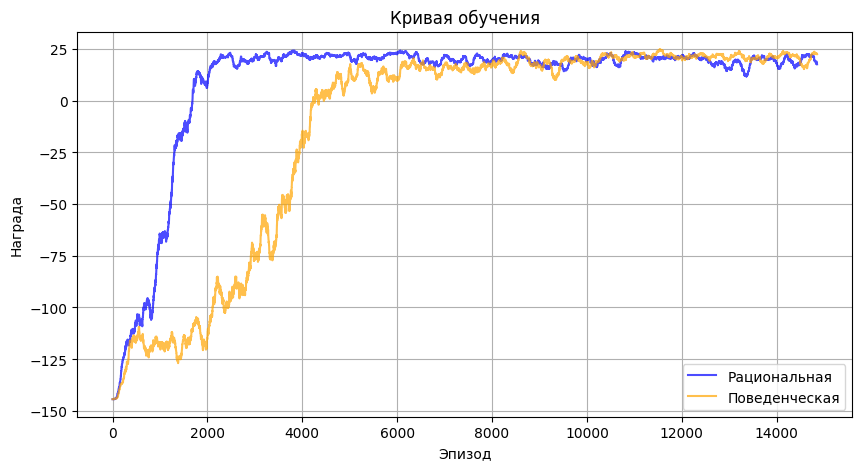

In [91]:
plt.figure(figsize=(10, 5))
plt.plot(moving_average(rat_hist), label='Рациональная', color='blue', alpha=0.7)
plt.plot(moving_average(pro_hist), label='Поведенческая', color='orange', alpha=0.7)
plt.title('Кривая обучения')
plt.xlabel('Эпизод'); plt.ylabel('Награда')
plt.legend(); plt.grid(True)
plt.show()

Видим, что поведенческий агент статистическм быстрее достигает цели, чем рациональный. Это связано с тем, что рациональный агент просто оптимизирует мат ожидание награды, в то время как поведенческий оптимизирует то, что действительно является полезным

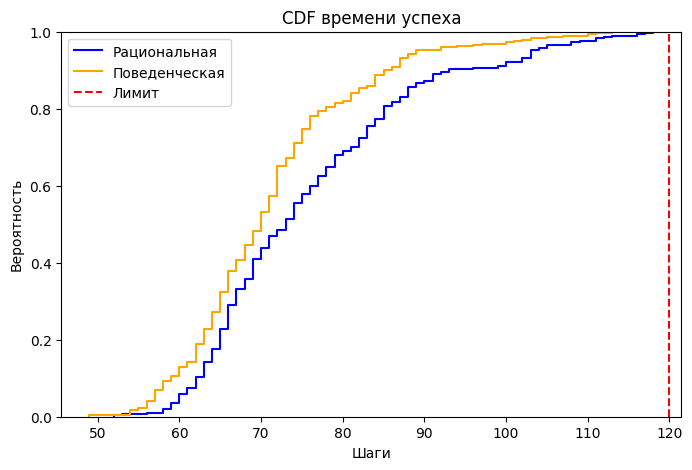

In [92]:
plt.figure(figsize=(8, 5))
if rat_stats['times']:
    sns.ecdfplot(rat_stats['times'], label='Рациональная', color='blue')
if pro_stats['times']:
    sns.ecdfplot(pro_stats['times'], label='Поведенческая', color='orange')
plt.axvline(120, color='red', linestyle='--', label='Лимит')
plt.title('CDF времени успеха')
plt.xlabel('Шаги'); plt.ylabel('Вероятность')
plt.legend(); plt.show()

Видим, что у рациональной модели чаще остается заряд в от 0.9225 до 0.9300, в то время, как у рациональной модели, в случае успеха, заряд часто остается равным 0.93 в связи с тем, что чаще выбирает один и тот же путь

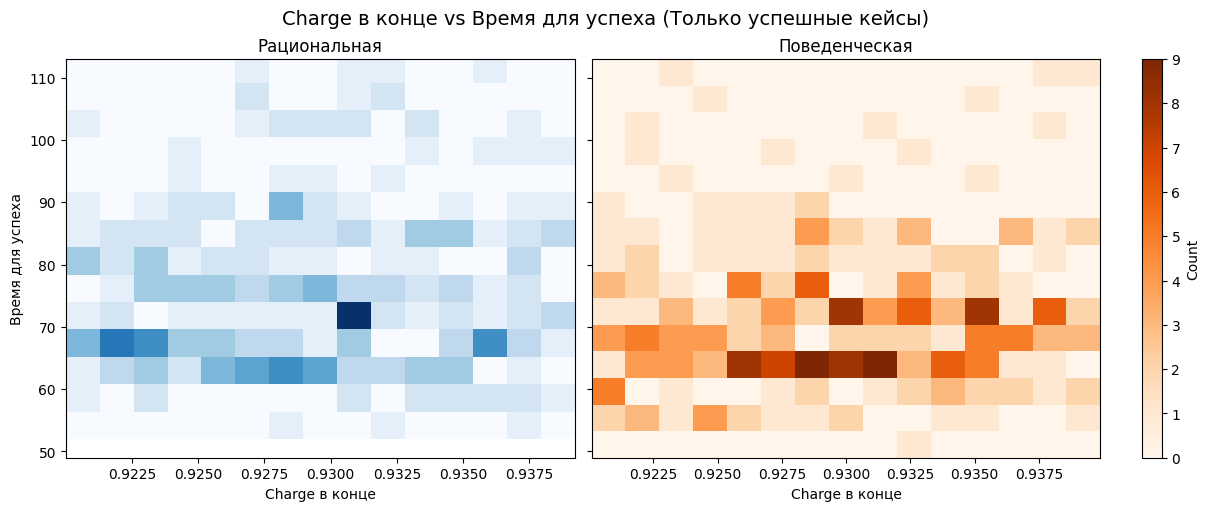

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
if len(rat_stats['charge_success']) > 0:
    h1 = axes[0].hist2d(rat_stats['charge_success'], rat_stats['times'], bins=15, cmap='Blues')
    axes[0].set_title('Рациональная')
    axes[0].set_xlabel('Charge в конце')
    axes[0].set_ylabel('Время для успеха')

if len(pro_stats['charge_success']) > 0:
    h2 = axes[1].hist2d(pro_stats['charge_success'], pro_stats['times'], bins=15, cmap='Oranges')
    axes[1].set_title('Поведенческая')
    axes[1].set_xlabel('Charge в конце')

if 'h2' in locals():
    fig.colorbar(h2[3], ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Count')

fig.suptitle('Charge в конце vs Время для успеха (Только успешные кейсы)', fontsize=14)
plt.show()

Видим, что траектории поведенческого агента безопаснее, они реже проходят вплотную к границам препятствий и имеют некоторую вариативность, в то время, как рациональная модель чаще выбирает один и тот же кратчайший путь

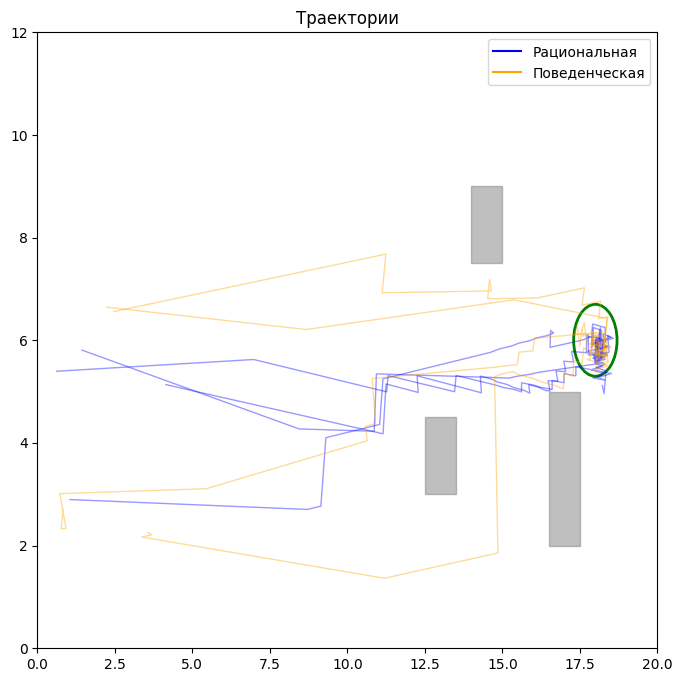

In [95]:
plt.figure(figsize=(8, 8))
for obs in OBSTACLES:
    rect = plt.Rectangle((obs[0], obs[2]), obs[1]-obs[0], obs[3]-obs[2], color='gray', alpha=0.5)
    plt.gca().add_patch(rect)
circle = plt.Circle(TARGET_POS, TARGET_RADIUS, color='green', fill=False, linewidth=2)
plt.gca().add_patch(circle)

for t in rat_stats['trajectories']:
    plt.plot(t['x'], t['y'], color='blue', alpha=0.4, linewidth=1)
for t in pro_stats['trajectories']:
    plt.plot(t['x'], t['y'], color='orange', alpha=0.4, linewidth=1)

plt.plot([], [], color='blue', label='Рациональная')
plt.plot([], [], color='orange', label='Поведенческая')
plt.xlim(0, 20); plt.ylim(0, 12)
plt.title('Траектории')
plt.legend()
plt.show()

Видим, что поведенческая модель чаще добирается до таргета и чаще избегает столкновений

Также видим, что среднее время до таргета и энергопотребление у поведенческой модели ниже.

Можно сделать вывод, что поведенческая модель, имитирующая человеческое мышление с точки зрения оценки рисков с λ=2.35, полученным эмпирически, действительно работает

In [169]:
  print(f"{'Метрика':<25} {'Рациональная'} | {'Поведенческая':<7}")
  print("-" * 60)
  print(f"{'Успех %':<30} {rat_stats['success']/300:7.3%} | {pro_stats['success']/300:.3%}")

  r_time = np.mean(rat_stats['times']) if rat_stats['times'] else 0
  p_time = np.mean(pro_stats['times']) if pro_stats['times'] else 0
  print(f"{'Среднее время':<30} {r_time:<7.3f} | {p_time:<10.3f}")

  r_eng = np.mean(rat_stats['energy_used']) if rat_stats['energy_used'] else 0
  p_eng = np.mean(pro_stats['energy_used']) if pro_stats['energy_used'] else 0
  print(f"{'Средний исползованный заряд':<30} {r_eng:<7.3f} | {p_eng:<10.3f}")

  print(f"{'Столкновения %':<30} {rat_stats['collisions']/300:7.3%} | {pro_stats['collisions']/300:.3%}")

Метрика                   Рациональная | Поведенческая
------------------------------------------------------------
Успех %                        96.667% | 97.667%
Среднее время                  75.886  | 71.212    
Средний исползованный заряд    1.188   | 1.095     
Столкновения %                 10.000% | 3.333%


Передед вычислением тестов и значимости, необходимо проверить нормальность тех распределений, для которых мы хотим использовать t-test. В данном случае это время в пути и использованный заряд. Определяю функцию для проверки на нормальность тестом Шапиро-Уилка

In [ ]:
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [215]:
def check_normality(data, alpha=0.05):
    stat, p = stats.shapiro(data)
    return p > alpha, f"Шапиро p={p:.10f}"

Видим, что ни одна из статистик не является нормально распределенной

In [216]:
def print_normality_check(data, agent_name, data_name):
      normal, info = check_normality(data)
      print(f"{agent_name} (n={len(data)}):")
      print(f"  {info}")
      print(f"  Нормальное распределение: {'ДА' if normal else 'НЕТ'}")

# нормальность для затраченного времени
print("Время в пути, успешные кейсы:")
print("-" * 50)
print_normality_check(rat_stats['times'], "Рациональный агент", "время выполнения")
print_normality_check(pro_stats['times'], "Поведенческий агент", "время выполнения")

# нормальность для использованного заряда
print("\nИспользованный заряд, успешные кейсы:")
print("-" * 50)
print_normality_check(rat_stats['energy_used'], "Рациональный агент", "использованный заряд")
print_normality_check(pro_stats['energy_used'], "Поведенческий агент", "использованный заряд")

Время в пути, успешные кейсы:
--------------------------------------------------
Рациональный агент (n=290):
  Шапиро p=0.0000000000
  Нормальное распределение: НЕТ
Поведенческий агент (n=293):
  Шапиро p=0.0000000001
  Нормальное распределение: НЕТ

Использованный заряд, успешные кейсы:
--------------------------------------------------
Рациональный агент (n=290):
  Шапиро p=0.0000000000
  Нормальное распределение: НЕТ
Поведенческий агент (n=293):
  Шапиро p=0.0000000002
  Нормальное распределение: НЕТ


Q-Q графики для наглядности

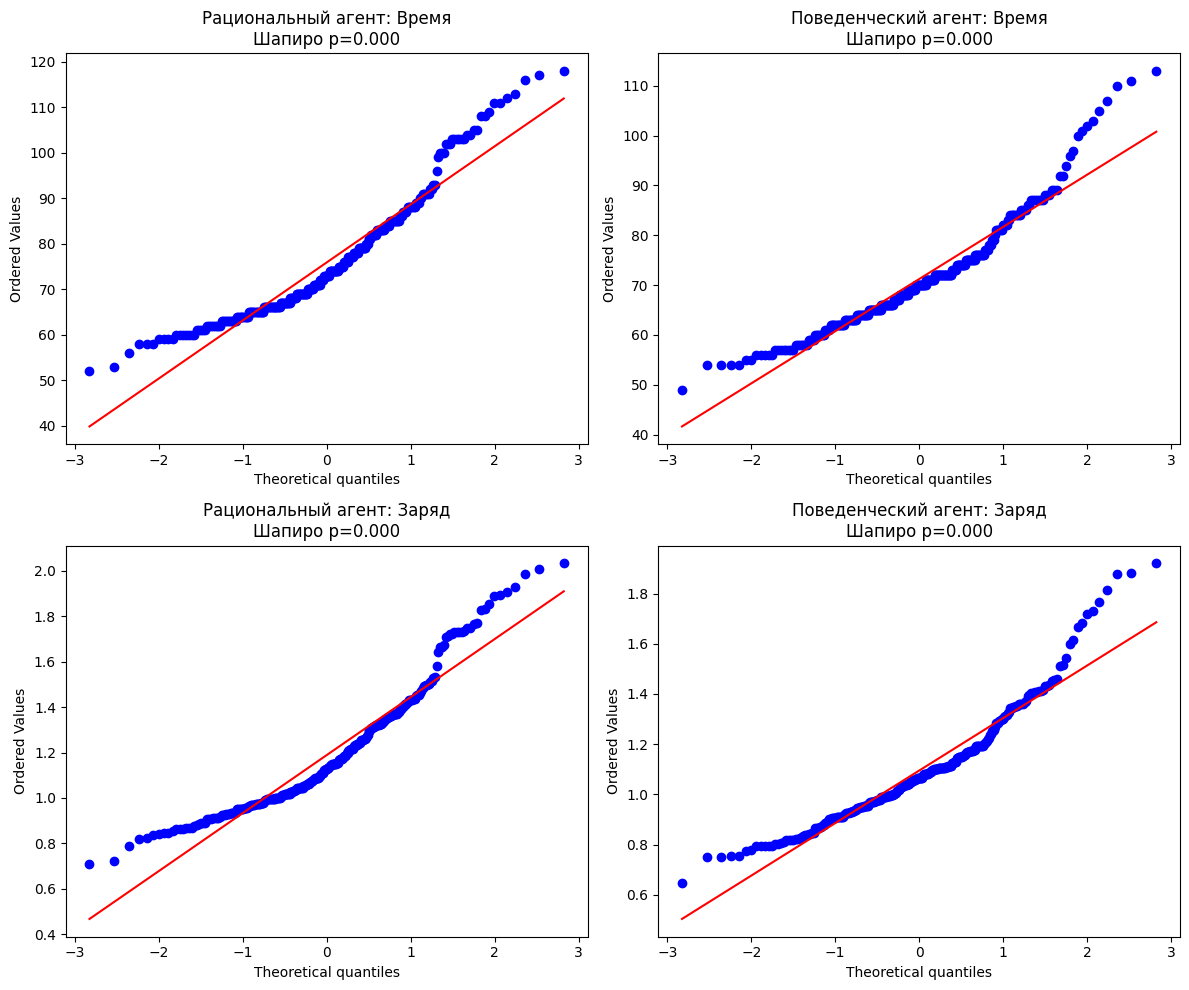

In [206]:
if rat_stats.get('times') and pro_stats.get('times'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    stats.probplot(rat_stats['times'], dist="norm", plot=axes[0, 0])
    axes[0, 0].set_title(f'Рациональный агент: Время\nШапиро p={check_normality(rat_stats["times"])[1].split("=")[1]}')

    stats.probplot(pro_stats['times'], dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title(f'Поведенческий агент: Время\nШапиро p={check_normality(pro_stats["times"])[1].split("=")[1]}')

    stats.probplot(rat_stats['energy_used'], dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f'Рациональный агент: Заряд\nШапиро p={check_normality(rat_stats["energy_used"])[1].split("=")[1]}')

    stats.probplot(pro_stats['energy_used'], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f'Поведенческий агент: Заряд\nШапиро p={check_normality(pro_stats["energy_used"])[1].split("=")[1]}')

    plt.tight_layout()
    plt.show()

Определяю функции для подсчета непараметрического Mann-Whitney test, Z-test для бинарных данных, и определения статистической значимости с alpha=0.05

In [230]:
def z_test(success_a, success_b, n_a=300, n_b=300):
    return proportions_ztest([success_a, success_b], [n_a, n_b], alternative='two-sided')[1]

def mannwhitney_test(data_a, data_b):
    return stats.mannwhitneyu(data_a, data_b, alternative='two-sided')[1]

def is_significant(p, alpha=0.01):
    return p < alpha if p is not None else False

Видим, что разница по всем статистикам, кроме успеха, статистически значима с alpha = 0.01 (соответственно и с 0.05 по ТЗ, аналогичные результаты)

In [231]:
print(f"{'Метрика':<20} {'Рациональная':<8} {'Поведческая':<8} {'p-value':<8} {'Значимо'}")
print("-" * 65)

# успешность, z-test
p_success = z_test(rat_stats['success'], pro_stats['success'])
print(f"{'Успех %':<25} {rat_stats['success']/300:7.3%} {pro_stats['success']/300:7.3%} {p_success:12.5e} {is_significant(p_success)}")

# средняя время, mann-whitney
p_time = mannwhitney_test(rat_stats['times'], pro_stats['times'])
r_time = np.mean(rat_stats['times']) if rat_stats['times'] else 0
p_time_val = np.mean(pro_stats['times']) if pro_stats['times'] else 0
print(f"{'Среднее время':<25} {r_time:7.3f} {p_time_val:7.3f} {p_time:12.5e} {is_significant(p_time)}")

# заряд в конце пути, mann-whitney
p_energy = mannwhitney_test(rat_stats['energy_used'], pro_stats['energy_used'])
r_eng = np.mean(rat_stats['energy_used']) if rat_stats['energy_used'] else 0
p_eng = np.mean(pro_stats['energy_used']) if pro_stats['energy_used'] else 0
print(f"{'Средний заряд':<25} {r_eng:7.3f} {p_eng:7.3f} {p_energy:12.5e} {is_significant(p_energy)}")

# столкновения, z-test
p_coll = z_test(rat_stats['collisions'], pro_stats['collisions'])
print(f"{'Столкновения %':<25} {rat_stats['collisions']/300:7.3%} {pro_stats['collisions']/300:7.3%} {p_coll:12.5e} {is_significant(p_coll)}")

Метрика              Рациональная Поведческая p-value  Значимо
-----------------------------------------------------------------
Успех %                   96.667% 97.667%  4.60430e-01 False
Среднее время              75.886  71.212  3.48114e-05 True
Средний заряд               1.188   1.095  2.62479e-05 True
Столкновения %            10.000%  3.333%  1.06311e-03 True


Делаем вывод, что в условиях неопределённости (случайные старты, ветер, препятствия) поведенческий агент, имитирующий человеческое неприятие потерь (λ=2.35), превосходит чисто рационального оптимизатора по балансу скорости, энергоэффективности и безопасности, сохраняя тот же уровень успешных поездок